> **Data required:** This notebook uses InSight HP³ data from Spohn et al. (2024). 
> If you haven't already, download the datasets from [FigShare](https://doi.org/10.6084/m9.figshare.25099754) 
> and place them in `resources/data/`. See [`resources/data/README.md`](../resources/data/README.md) for details.

/mnt/c/ai-in-physics/cfd-ai-journey/.venv-linux/lib/python3.12/site-packages/openpyxl/reader/drawings.py:67: UserWarning: wmf image format is not supported so the image is being dropped
  warn(msg)


Iteration 1000/200000, Loss: 404.736725
BC edges: 91.286423
Physics:  0.157814
Data:  61.111919
kappa: 1.8054e-08
Iteration 2000/200000, Loss: 70.026932
BC edges: 11.789728
Physics:  0.101866
Data:  10.628777
kappa: 1.1619e-08
Iteration 3000/200000, Loss: 17.643387
BC edges: 2.940877
Physics:  0.054628
Data:  2.394220
kappa: 9.7415e-09
Iteration 4000/200000, Loss: 7.456861
BC edges: 0.820978
Physics:  0.032282
Data:  1.004360
kappa: 9.1101e-09
Iteration 5000/200000, Loss: 4.659611
BC edges: 0.274104
Physics:  0.026961
Data:  0.607489
kappa: 8.7371e-09
Iteration 6000/200000, Loss: 3.634904
BC edges: 0.108278
Physics:  0.028794
Data:  0.417389
kappa: 8.4932e-09
Iteration 7000/200000, Loss: 2.423112
BC edges: 0.054200
Physics:  0.018826
Data:  0.285519
kappa: 8.3243e-09
Iteration 8000/200000, Loss: 1.507430
BC edges: 0.036068
Physics:  0.010268
Data:  0.191596
kappa: 8.2157e-09
Iteration 9000/200000, Loss: 1.308617
BC edges: 0.030332
Physics:  0.012400
Data:  0.131657
kappa: 8.1489e-09
It

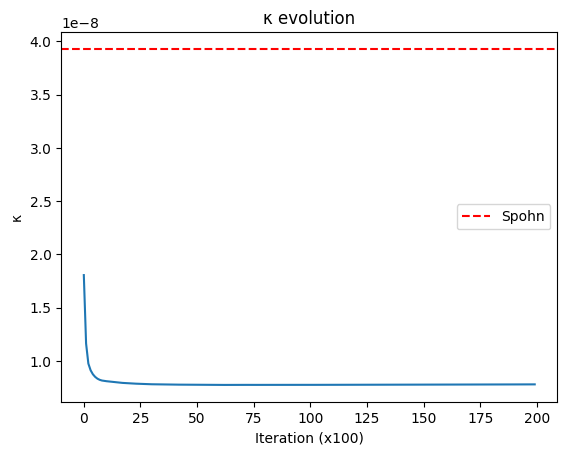

In [8]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy

# Problem parameters
kappa = 3.93e-8       # thermal diffusivity [m^2/s]
z_min = 0             # surface
z_max = 0.4           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

z_0 = 0.017           # Top of mole
z_1 = 0.363           # bottom of mole

avg_bottom_temp = 225.6  # average bottom temperature (K)


# Import fourier coefficients for amalytical solutions at the boundaries

import pickle

with open('../../resources/data/fourier_coefficients.pkl', 'rb') as f:
    coeffs = pickle.load(f)


# TEM-A Sol 1202 = mole temperature over one sol (the warmest sol sampled)
# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)

wb_diurnal = openpyxl.load_workbook(
    '../../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    # Column index 6 = 'LTST Conversion step 2' (hours, 0-24)
    # Column index 7 = 'average T15, T16' (Kelvin)
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass


# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass


# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_mole = [t * sol_seconds / 24 for t in ltst_mole]
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


key = random.PRNGKey(0)
key, key1, key2, key3, key4, key5, key6 = random.split(key, 7)


#-------- 1. Boundary Condition points used for Perturbation network --------
n_surface = len(ltst_surf)  # Should be 552


# Surface boundary (x=0). No perturbation on the surface temperature.:
t_bc_surface = random.uniform(key2, (n_surface, 1), minval=0, maxval=sol_seconds) # (552, 1)
x_bc_surface = jnp.zeros((n_surface, 1))
u_bc_surface = jnp.zeros((n_surface, 1))  # (552, 1)


# Bottom boundary (x=depth):
t_bc_bottom = random.uniform(key5, (n_surface, 1), minval=0, maxval=sol_seconds) # (552, 1)
x_bc_bottom = jnp.ones((n_surface, 1)) * z_max

u_bc_bottom = jnp.zeros((n_surface, 1))  # (552, 1)

## Boudnaries at top and bottom of mole. mole is isothermal, so we will enforce the same temperature at the top and bottom of the mole. 

# Mole top boundary (z = z_0))
t_bc_mole_top = jnp.array(ltst_mole).reshape(-1, 1)# 5550 points from the mole temperature data
x_bc_mole_top = jnp.ones((len(ltst_mole), 1)) * z_0


# Mole bottom boundary (z = z_1))
t_bc_mole_bottom = jnp.array(ltst_mole).reshape(-1, 1)# 5550 points from the mole temperature data
x_bc_mole_bottom = jnp.ones((len(ltst_mole), 1)) * z_1


u_bc_mole = jnp.array(temp_mole).reshape(-1, 1)

# #Join all bcs except the mole surface

# t_bc = jnp.concatenate([t_bc_surface, t_bc_bottom])
# x_bc = jnp.concatenate([x_bc_surface, x_bc_bottom])
# u_bc = jnp.concatenate([u_bc_surface, u_bc_bottom])  

# 2. Physics collocation points (50 * 50 = 2500 points). Soil is only on the top and bottom
t_physics_top = random.uniform(key1, (2500, 1), minval=0, maxval=sol_seconds)
x_physics_top = random.uniform(key2, (2500, 1), minval=0, maxval=z_0)

t_physics_bottom = random.uniform(key3, (2500, 1), minval=0, maxval=sol_seconds)
x_physics_bottom = random.uniform(key4, (2500, 1), minval=z_1, maxval=z_max)

# Normalise the data so the network only sees values of order 1. This helps with training stability and convergence. We will need to un-normalise the predictions later to compare with the original data.

# Normalisation parameters
t_min, t_max = 0.0, sol_seconds
x_min, x_max = 0.0, z_max
u_min, u_max = 185.0, 300.0  # Based on the range of temperatures in the data

def normalize_t(t): return ( t - t_min) / (t_max - t_min)
def normalize_x(x): return ( x - x_min) / (x_max - x_min)

# Top region: z ∈ [0, z_0] → [0, 1]
def normalize_z_top(z): return z / z_0

# Bottom region: z ∈ [z_1, z_max] → [0, 1]  
def normalize_z_bottom(z): return (z - z_1) / (z_max - z_1)


# Normalize all data

t_bc_surface = normalize_t(t_bc_surface)
x_bc_surface = normalize_z_top(x_bc_surface)

t_bc_bottom = normalize_t(t_bc_bottom)
x_bc_bottom = normalize_z_bottom(x_bc_bottom)


t_physics_top = normalize_t(t_physics_top)
x_physics_top = normalize_z_top(x_physics_top)

t_physics_bottom = normalize_t(t_physics_bottom)
x_physics_bottom = normalize_z_bottom(x_physics_bottom)

#Normalize kappa as well (since it appears in the physics residual)
def normalize_kappa(kappa):
    return kappa * (t_max - t_min) / ((x_max - x_min)**2)

def normalize_kappa_top(kappa):
    return kappa * (t_max - t_min) / ((z_0)**2)

def normalize_kappa_bottom(kappa):
    return kappa * (t_max - t_min) / ((z_max - z_1)**2)

# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.

    Args:
        layer_sizes: List of layer sizes, e.g., [2, 32, 32, 32, 1]
                    (input_dim, hidden1, hidden2, hidden3, output_dim)
        key: JAX random key for initialization

    Returns:
        params: List of dictionaries, each containing 'w' and 'b'
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))

    params = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]

        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])

        # Xavier initialization for weights
        params.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })

    return params


def network(params, x):
    """
    Forward pass through the network.

    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)
        region: String indicating the region ('top' or 'bottom')
    Returns:
        Output array, shape (batch_size, output_dim)
    """
    # Process all hidden layers (all but last)



    for layer in params[:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)

    # Output layer (no activation)
    final_layer = params[-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']
    

    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point, kappa):

    def u(t_val, x_val):
        tx_in = jnp.array([[t_val, x_val]])
        return network(params, tx_in)[0, 0]
    
    du_dt = grad(u, argnums=0)(t_point, x_point)

    d2u_dx2 = grad(grad(u, argnums = 1), argnums=1)(t_point, x_point)


    return du_dt / kappa - d2u_dx2

physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0, None))

# Solve every point Analytacly using the Fourier series solution for the undisturbed soil temperature. 
def T_1D(A_n, phi_n, T_mean, N_harmonics, omega):
    """undisturbed soil temperature - Fourier Series"""
    n_vals = jnp.arange(1, N_harmonics + 1)
    An = A_n[1:N_harmonics + 1]
    phin = phi_n[1:N_harmonics + 1]

    @jit
    def T_analytical(t, z, kappa):
        # Skin depths recomputed each call using current kappa
        delta_n = jnp.sqrt(2 * kappa / (n_vals * omega))
        u_far = T_mean + jnp.sum(
            An * jnp.exp(-z / delta_n) * jnp.cos(n_vals * omega * t - z / delta_n + phin)
        )

        return u_far

    return T_analytical


# Vectorize to handle all physics points at once

T_far = T_1D(
    jnp.array(coeffs['A_n']),
    jnp.array(coeffs['phi_n']),
    coeffs['T_mean'],
    coeffs['N_harmonics'],
    coeffs['omega']
)

T_sol_batch = vmap(T_far, in_axes=(0, 0, None))


# Initialize network
key = random.PRNGKey(123)
key, key1 = random.split(key)
layer_sizes = [2, 32, 32, 32, 1]  # 2 inputs (t, x), 1 output (u)
# Two networks, one per soil region
params_top = init_network_params(layer_sizes, key)
params_bot = init_network_params(layer_sizes, key1)

with open('forward_checkpoint/forward_warmstart_3.93e-8.pkl', 'rb') as f:
    forward_params = pickle.load(f)

params = {
    'top': params_top,
    'bottom': params_bot,  # Start with the same parameters for the bottom network
    'log_kappa': jnp.log(kappa)  # deliberately wrong — 2.5x too high
}



# Initialize optimizer
learning_rate = 1e-3
# schedule = optax.piecewise_constant_schedule(init_value=learning_rate, boundaries_and_scales={40000: 0.1, 80000: 0.01})
# optimizer = optax.adam(schedule)
# opt_state = optimizer.init(params)

schedule = optax.piecewise_constant_schedule(init_value=learning_rate, boundaries_and_scales={80000: 0.1})

optimizer = optax.multi_transform(
    {'kappa': optax.adam(schedule), 'nn': optax.adam(1e-3)},
    param_labels={'top': 'nn', 'bottom': 'nn', 'log_kappa': 'kappa'}
)
opt_state = optimizer.init(params)


@jit
def update_step(params, opt_state,
                t_bc_surface, x_bc_surface, t_bc_bottom, x_bc_bottom, u_bc_surface,
                t_bc_mole_top, x_bc_mole_top, t_bc_mole_bottom, x_bc_mole_bottom, u_bc_mole,
                t_physics_top, x_physics_top, t_physics_bottom, x_physics_bottom):

    def loss_fn(params):

        # 1. Boundary Condition Loss. Surfaceand bottom
        tx_bc_surface = jnp.concatenate([t_bc_surface, x_bc_surface], axis=1)
        tx_bc_bottom = jnp.concatenate([t_bc_bottom, x_bc_bottom], axis=1)

        u_pred_bc_surface = network(params['top'], tx_bc_surface)
        u_pred_bc_bottom = network(params['bottom'], tx_bc_bottom)
        bc_loss_edges = jnp.mean((u_pred_bc_surface - u_bc_surface)**2) + jnp.mean((u_pred_bc_bottom - u_bc_surface)**2)

        kappa = jnp.exp(params['log_kappa'])  # If we are treating kappa as a trainable parameter, we need to exponentiate it to ensure positivity

        # Boundary condition at mole surface (top)
        u_pred_mole_top = network(params['top'], jnp.concatenate([normalize_t(t_bc_mole_top), normalize_z_top(x_bc_mole_top)], axis=1))
        T_1d_top = T_sol_batch(t_bc_mole_top.ravel(), x_bc_mole_top.ravel(), kappa).reshape(-1, 1)
        T_total_top = T_1d_top + u_pred_mole_top  # network already evaluated above

        # Boundary condition at mole surface (bottom)
        u_pred_mole_bottom = network(params['bottom'], jnp.concatenate([normalize_t(t_bc_mole_bottom), normalize_z_bottom(x_bc_mole_bottom)], axis=1))
        T_1d_bot = T_sol_batch(t_bc_mole_bottom.ravel(), x_bc_mole_bottom.ravel(), kappa).reshape(-1, 1)
        T_total_bot = T_1d_bot + u_pred_mole_bottom


        data_loss = jnp.mean((T_total_top - u_bc_mole)**2) + jnp.mean((T_total_bot - u_bc_mole)**2)

        # 2. Physics Loss
        kappa_top = normalize_kappa_top(kappa)
        kappa_bot = normalize_kappa_bottom(kappa)
        physics_residuals_top = physics_residual_batch(params['top'],
                                                t_physics_top.ravel(),
                                                x_physics_top.ravel(),
                                                kappa_top)
        physics_residuals_bottom = physics_residual_batch(params['bottom'],
                                                t_physics_bottom.ravel(),
                                                x_physics_bottom.ravel(),
                                                kappa_bot)
        physics_loss = jnp.mean(physics_residuals_top**2) + jnp.mean(physics_residuals_bottom**2) # Physics residual is of 10000 points.

        w_edges = 1.0
        w_data = 5.0  
        w_phys = 50.0


        return  w_edges * bc_loss_edges  + w_phys * physics_loss + w_data * data_loss , (bc_loss_edges, physics_loss, data_loss)

        # Compute loss and gradients
    (loss_val, individual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)

    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)

    return new_params, new_opt_state, loss_val, individual_loss


# Training parameters
num_iterations = 200000
save_every = 1000
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []



# Training loop
losses = []
losses_bc_edges = []
losses_phys = []
losses_data = []
kappa_history = []
for i in range(num_iterations):
    params, opt_state, loss, individual_loss = update_step(
                params, opt_state,
                t_bc_surface, x_bc_surface, t_bc_bottom, x_bc_bottom, u_bc_surface,
                t_bc_mole_top, x_bc_mole_top, t_bc_mole_bottom, x_bc_mole_bottom, u_bc_mole,
                t_physics_top, x_physics_top, t_physics_bottom, x_physics_bottom)

    losses.append(loss)
    losses_bc_edges.append(individual_loss[0])
    losses_phys.append(individual_loss[1])
    losses_data.append(individual_loss[2])

    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)


    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")
        print(f"BC edges: {individual_loss[0]:.6f}")
        print(f"Physics:  {individual_loss[1]:.6f}")
        print(f"Data:  {individual_loss[2]:.6f}")

    if (i + 1) % print_every == 0:
        print(f"kappa: {jnp.exp(params['log_kappa']):.4e}")
        kappa_history.append(float(jnp.exp(params['log_kappa'])))

# after training:
plt.figure()
plt.plot(kappa_history)
plt.xlabel('Iteration (x100)'); plt.ylabel('κ'); plt.title('κ evolution')
plt.axhline(3.93e-8, color='r', ls='--', label='Spohn')
plt.legend(); plt.show()

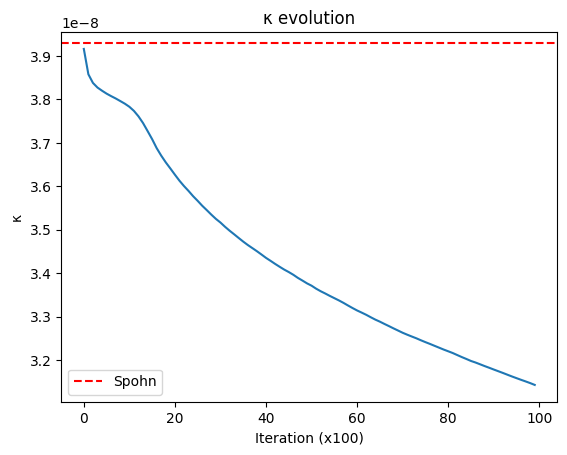

In [11]:

# after training:
plt.figure()
plt.plot(kappa_history)
plt.xlabel('Iteration (x100)'); plt.ylabel('κ'); plt.title('κ evolution')
plt.axhline(3.93e-8, color='r', ls='--', label='Spohn')
plt.legend(); plt.show()